In [63]:
# import libraries needed in work book
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Will work on dynamically setting filepath soon
file_path = "csv/cleaned_csv/pp-test-1000prems_cleaned_data.csv"

df = pd.read_csv(file_path, index_col=0)
# clean up date
df['date_of_transfer'] = pd.to_datetime(df['date_of_transfer'], errors='coerce') # turn date into datetime value

In [64]:
df_original = df.copy() # Create a copy of the df to avoid corrupting the data
# Add a Year Col, then using the year col add an year average price column
df_original['year_of_transfer'] = df_original['date_of_transfer'].dt.year # add a column with just the year for agg purposes. dt.year gives me an int. dt.strftime('%Y') gives a string

In [ ]:
top_4_counties = df_original['county'].value_counts().head(4).index
df_top_4 = df_original[df_original['county'].isin(top_4_counties)].copy() # set df to top 4 counties
# create the average on only the DF containing the top 4, instead of getting an average of the whole DF:
average_type = 'mean' # set average type for aggregation.
df_top_4['year_avg_sale'] = df_top_4.groupby('year_of_transfer')['price'].transform(average_type)

average_type = average_type.capitalize() # for the title of the graph



In [ ]:
# create pivot with years along the top, and counties on the index
df_pivot = df_top_4.pivot_table(
    values='price',
    index='county',
    columns='year_of_transfer',
    aggfunc='mean'
)
df_pivot = df_pivot.fillna(df_top_4.groupby("year_of_transfer")["year_avg_sale"].first()) # fill Na using the bottom three lines of code in the cell above.

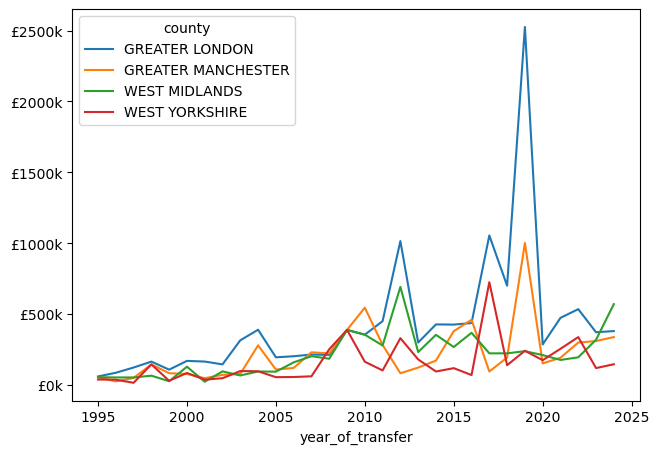

In [67]:
fig, ax = plt.subplots()

df_pivot.T.plot( # .T.transposes the DF to swap the X & Y axis.
    kind='line',
    ax=ax
    )
plt.tight_layout()

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'£{int(y/1000)}k')) # Formats the Y ticks to £100k etc
plt.show()